In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Setup Successful!")

Setup Successful!


In [2]:
import pandas as pd

df = pd.read_csv("../data/Superstore_Sales_Dataset.csv")

df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,12-06-2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print(df.shape)

(9993, 20)


In [4]:
print(df.columns)

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9993 non-null   str    
 1   Order Date     9993 non-null   str    
 2   Ship Date      9993 non-null   str    
 3   Ship Mode      9993 non-null   str    
 4   Customer ID    9993 non-null   str    
 5   Customer Name  9993 non-null   str    
 6   Segment        9993 non-null   str    
 7   Country        9993 non-null   str    
 8   City           9993 non-null   str    
 9   State          9993 non-null   str    
 10  Postal Code    9993 non-null   int64  
 11  Region         9993 non-null   str    
 12  Product ID     9993 non-null   str    
 13  Category       9993 non-null   str    
 14  Sub-Category   9993 non-null   str    
 15  Product Name   9993 non-null   str    
 16  Sales          9993 non-null   float64
 17  Quantity       9993 non-null   int64  
 18  Discount       9993

In [7]:
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000
mean,55191.576403,229.852846,3.789753,0.156188,28.660971
std,32065.074478,623.276074,2.225149,0.206457,234.271476
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.731000
50%,56560.000000,54.480000,3.000000,0.200000,8.671000
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))

Total Sales: 2296919.49
Total Profit: 286409.08


In [11]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)

top_products.head()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

In [12]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         836154.0330
Furniture          741718.4233
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [13]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

print(category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18463.3316
Name: Profit, dtype: float64


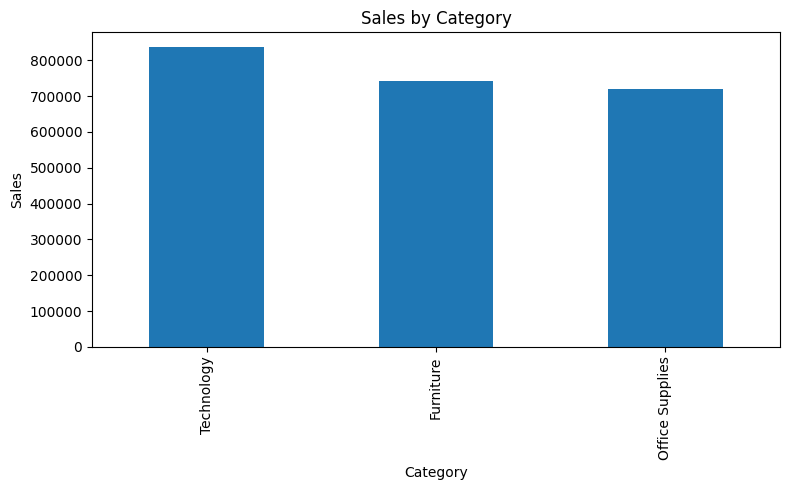

In [15]:
import matplotlib.pyplot as plt

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.tight_layout()

plt.savefig('../screenshots/sales_by_category.png')

plt.show()

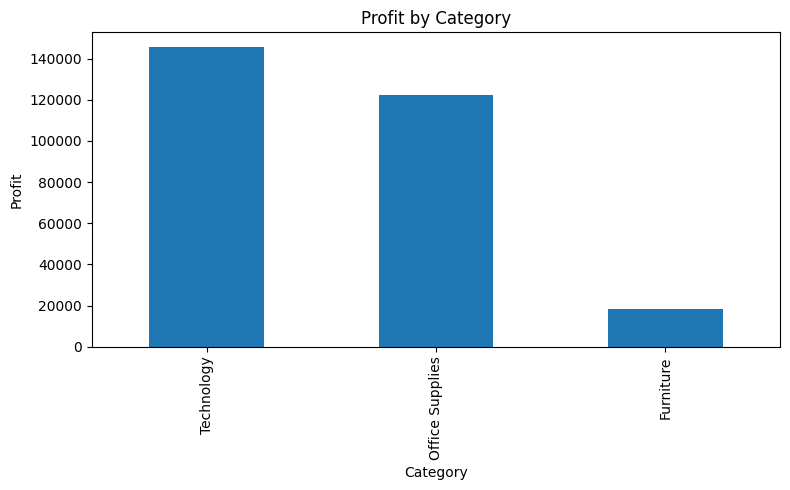

In [16]:
import matplotlib.pyplot as plt

category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_profit.plot(kind='bar')

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')

plt.tight_layout()

plt.savefig('../screenshots/profit_by_category.png')

plt.show()

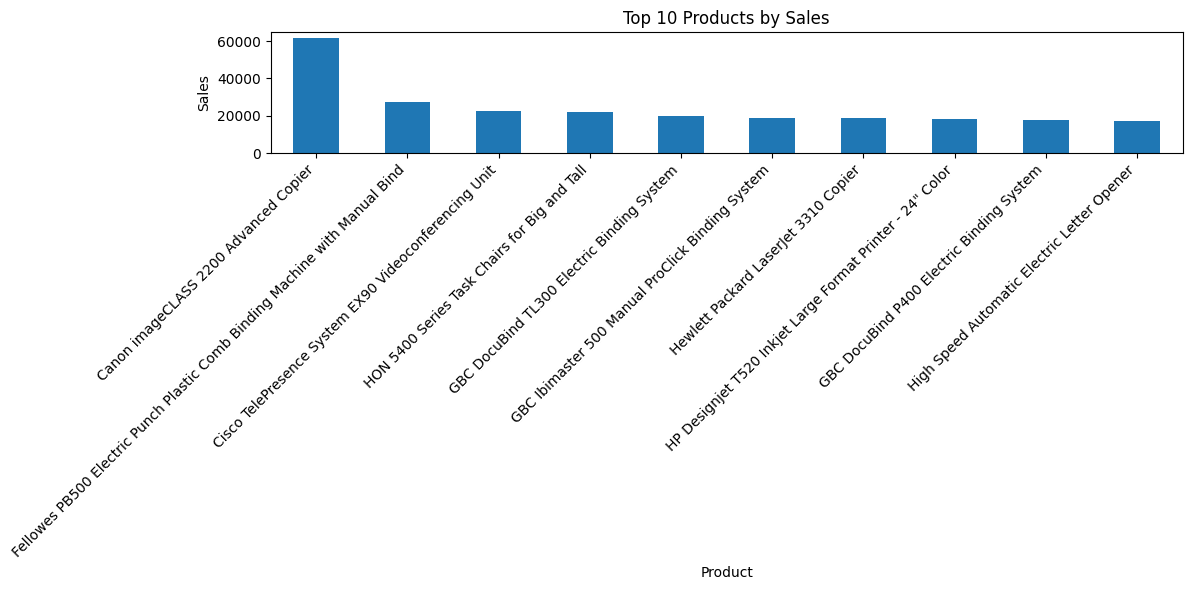

In [18]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar')

plt.title('Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Sales')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.savefig('../screenshots/top_10_products.png', bbox_inches='tight')

plt.show()

In [20]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

df['Year'] = df['Order Date'].dt.year

yearly_sales = df.groupby('Year')['Sales'].sum()

print(yearly_sales)

Year
2014    483966.1261
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


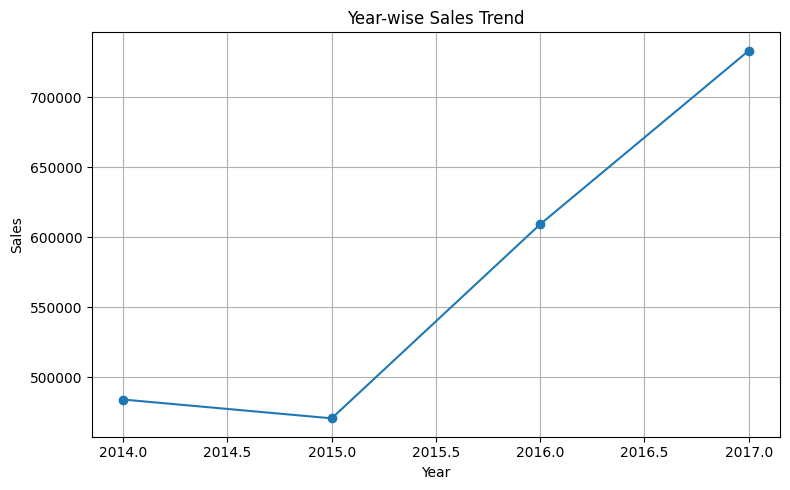

In [21]:
import matplotlib.pyplot as plt

yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(8,5))

plt.plot(yearly_sales.index,
         yearly_sales.values,
         marker='o')

plt.title('Year-wise Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales')

plt.grid(True)

plt.tight_layout()

plt.savefig('../screenshots/yearly_sales_trend.png')

plt.show()

In [22]:
yearly_profit = df.groupby('Year')['Profit'].sum()

print(yearly_profit)

Year
2014    49556.0329
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64
